In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from google.colab import files
uploaded = files.upload()

Saving dataset.csv to dataset (1).csv


In [5]:
df = pd.read_csv("Dataset.csv")

**Checking the Dataset**

In [6]:
df.head() #View first 5 rows

,ID,Name,Role,Transcript,Resume,decision,Reason_for_decision,Job_Description
0,jasojo159,Jason Jones,E-commerce Specialist,"Interviewer: Good morning, Jason. It's great t...",Here's a professional resume for Jason Jones:\...,reject,Lacked leadership skills for a senior position.,Be part of a passionate team at the forefront ...
1,annma759,Ann Marshall,Game Developer,Interview Scene\n\nA conference room with a ta...,Here's a professional resume for Ann Marshall:...,select,Strong technical skills in AI and ML.,Help us build the next-generation products as ...
2,patrmc729,Patrick Mcclain,Human Resources Specialist,Interview Setting: A conference room in a medi...,Here's a professional resume for Patrick Mccla...,reject,Insufficient system design expertise for senio...,We need a Human Resources Specialist to enhanc...
3,patrgr422,Patricia Gray,E-commerce Specialist,Here's a simulated professional interview for ...,Here's a professional resume for Patricia Gray...,select,Impressive leadership and communication abilit...,Be part of a passionate team at the forefront ...
4,amangr696,Amanda Gross,E-commerce Specialist,Here's the simulated interview:\n\nInterviewer...,Here's a professional resume for Amanda Gross:...,reject,Lacked leadership skills for a senior position.,We are looking for an experienced E-commerce S...


In [7]:
df.info() #Check structure

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10174 entries, 0 to 10173
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   10174 non-null  object
 1   Name                 10174 non-null  object
 2   Role                 10174 non-null  object
 3   Transcript           10174 non-null  object
 4   Resume               10174 non-null  object
 5   decision             10174 non-null  object
 6   Reason_for_decision  10174 non-null  object
 7   Job_Description      10174 non-null  object
dtypes: object(8)
memory usage: 636.0+ KB


In [8]:
df.describe() #Check statistics

,ID,Name,Role,Transcript,Resume,decision,Reason_for_decision,Job_Description
count,10174,10174,10174,10174,10174,10174,10174,10174
unique,10171,8677,45,10174,10174,2,539,3446
top,krisbr553,Lucas,Data Scientist,Here's a simulated interview for a Product Man...,"Here's a sample resume for Charlie Miller, a P...",reject,Insufficient system design expertise for senio...,Join our team as a Product Manager and leverag...
freq,2,21,538,1,1,5114,730,103


**Fix Missing Data**

In [9]:
df.isnull().sum() #Fix Missing Data

,0
ID,0
Name,0
Role,0
Transcript,0
Resume,0
decision,0
Reason_for_decision,0
Job_Description,0


**Fix Missing Data**

1.  df = df.dropna() #If missing values exist
2.  More safer way:
df.fillna(0, inplace=True)





**DATA CLEANING**



In [13]:
df.drop_duplicates(inplace=True)#  Remove duplicates

df.dropna(inplace=True)  # Remove missing values

print("Missing Values:")

print("\n")

print(df.isnull().sum())


Missing Values:


ID                     0
Name                   0
Role                   0
Transcript             0
Resume                 0
decision               0
Reason_for_decision    0
Job_Description        0
dtype: int64


**BASIC EDA**

decision
reject    5114
select    5060
Name: count, dtype: int64


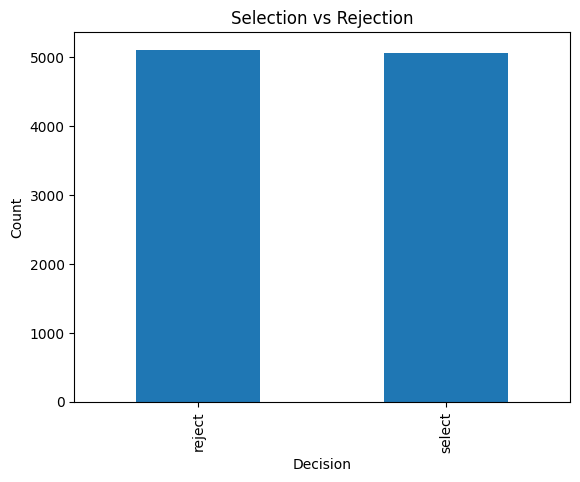

In [14]:

print(df['decision'].value_counts())  ## Decision count

df['decision'].value_counts().plot(kind='bar')# Plot decision distribution

plt.title("Selection vs Rejection")
plt.xlabel("Decision")
plt.ylabel("Count")
plt.show()

**TEXT CLEANING FUNCTION**

In [27]:
import nltk
import re
import string

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# download nltk data
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [28]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):

    text = str(text).lower()

    text = re.sub(r"http\S+", "", text)  # remove urls

    text = re.sub(r"\d+", "", text)   # remove numbers

    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation

    words = text.split()  # tokenize

    # remove stopwords + lemmatize
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)


**CLEAN TEXT COLUMNS**

In [29]:
text_columns = [
    'Resume',
    'Transcript',
    'Job_Description'
]

for col in text_columns:
    df[col] = df[col].apply(clean_text)

print(df.head())

          ID             Name                        Role  \
0  jasojo159      Jason Jones       E-commerce Specialist   
1   annma759     Ann Marshall              Game Developer   
2  patrmc729  Patrick Mcclain  Human Resources Specialist   
3  patrgr422    Patricia Gray       E-commerce Specialist   
4  amangr696     Amanda Gross       E-commerce Specialist   

                                          Transcript  \
0  interviewer good morning jason great meet welc...   
1  interview scene conference room table two chai...   
2  interview setting conference room mediumsized ...   
3  here simulated professional interview ecommerc...   
4  here simulated interview interviewer good morn...   

                                              Resume  decision  \
0  here professional resume jason jones jason jon...         0   
1  here professional resume ann marshall ann mars...         1   
2  here professional resume patrick mcclain patri...         0   
3  here professional resume patr

**CREATE COMBINED TEXT**

In [17]:
df['combined_text'] = (
    df['Resume'] + " " +
    df['Transcript'] + " " +
    df['Job_Description']
)


**WORD CLOUD**

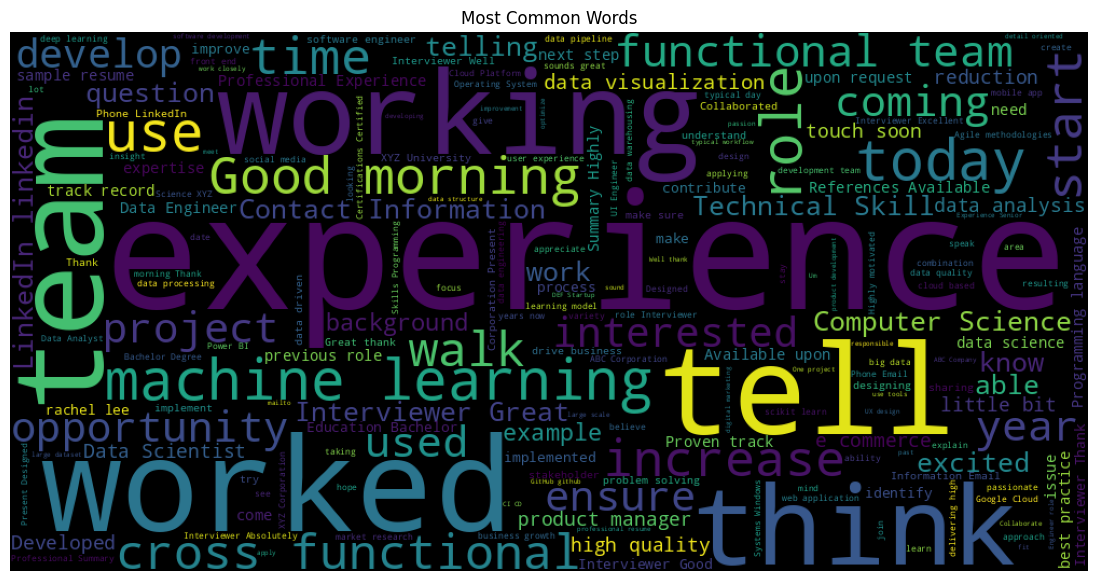

In [31]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

all_text = " ".join(df['combined_text'])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='black'
).generate(all_text)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Most Common Words")
plt.show()


**TF-IDF FEATURE ENGINEERING**

In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [33]:
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['combined_text'])

**TARGET VARIABLE**

In [20]:
# Convert labels to numbers

df['decision'] = df['decision'].map({
    'select': 1,
    'reject': 0
})

y = df['decision']

**TRAIN TEST SPLIT**

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

NameError: name 'train_test_split' is not defined

**LOGISTIC REGRESSION MODEL**

In [22]:
lr_model = LogisticRegression()

lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)

print("\nLOGISTIC REGRESSION ACCURACY")
print(accuracy_score(y_test, lr_preds))

print("\nClassification Report")
print(classification_report(y_test, lr_preds))

NameError: name 'LogisticRegression' is not defined

**RANDOM FOREST MODEL**

In [23]:
rf_model = RandomForestClassifier()

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

print("\nRANDOM FOREST ACCURACY")
print(accuracy_score(y_test, rf_preds))


NameError: name 'RandomForestClassifier' is not defined

**XGBOOST MODEL**

In [ ]:
xgb_model = XGBClassifier()

xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)

print("\nXGBOOST ACCURACY")
print(accuracy_score(y_test, xgb_preds))

**CONFUSION MATRIX**

In [ ]:
cm = confusion_matrix(y_test, xgb_preds)

print("\nConfusion Matrix")
print(cm)

**FEATURE IMPORTANCE**

In [24]:
importance = xgb_model.feature_importances_

feature_names = vectorizer.get_feature_names_out()

feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importance
})

feature_importance_df = feature_importance_df.sort_values(
    by='importance',
    ascending=False
)

print("\nTop Important Words")
print(feature_importance_df.head(20))

NameError: name 'xgb_model' is not defined

**RESUME MATCHING SYSTEM**

In [ ]:
resume = """
python machine learning deep learning flask api
"""

job_description = """
looking for python developer with machine learning experience
"""

resume_clean = clean_text(resume)
job_clean = clean_text(job_description)

texts = [resume_clean, job_clean]

match_vector = TfidfVectorizer()

matrix = match_vector.fit_transform(texts)

similarity = cosine_similarity(matrix[0:1], matrix[1:2])

print("\nResume Match Percentage:")
print(round(similarity[0][0] * 100, 2), "%")

**PREDICTION SYSTEM**

In [25]:
def predict_candidate(resume, transcript, job_desc):

    text = (
        clean_text(resume) + " " +
        clean_text(transcript) + " " +
        clean_text(job_desc)
    )

    vector = vectorizer.transform([text])

    prediction = xgb_model.predict(vector)[0]

    probability = xgb_model.predict_proba(vector)[0]

    if prediction == 1:
        result = "SELECTED"
    else:
        result = "REJECTED"

    print("\nPrediction:", result)

    print("Confidence:")
    print("Reject:", round(probability[0] * 100, 2), "%")
    print("Select:", round(probability[1] * 100, 2), "%")

**TEST PREDICTION**

In [26]:
sample_resume = """
Experienced AI engineer skilled in Python, Machine Learning,
TensorFlow, Flask, NLP, and Deep Learning.
"""

sample_transcript = """
I have worked on several AI projects and deployed models
using Flask APIs.
"""

sample_job = """
Need an AI engineer with strong Python and ML experience.
"""

predict_candidate(
    sample_resume,
    sample_transcript,
    sample_job
)


NameError: name 'clean_text' is not defined